# Aggregation Levels Diagram

Illustrative diagram showing how raw event data is aggregated into three
different levels of observation (season, match, scoreline). Color-coded
column headers indicate the role of each variable.

No real data is loaded — all table content is hypothetical/illustrative.


In [1]:
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'

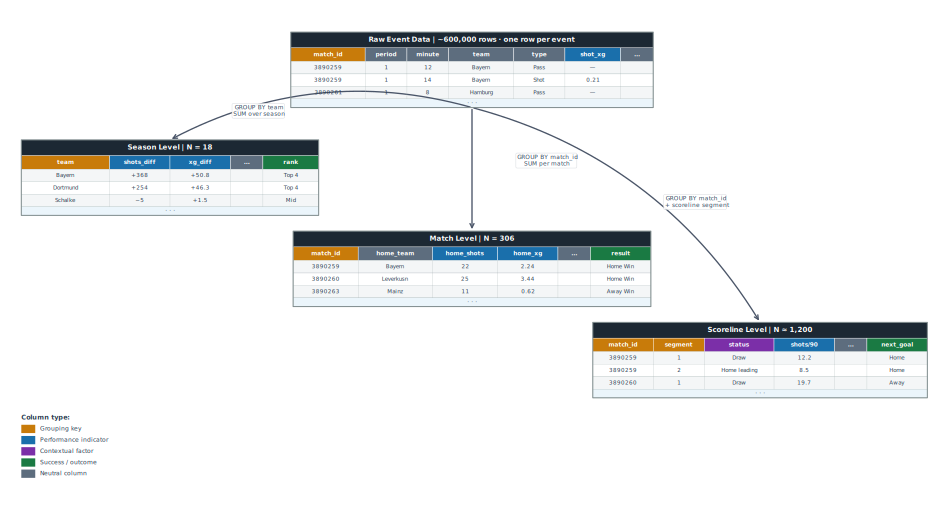

In [ ]:
#| label: fig-aggregation-levels
#| fig-cap: "Illustration of three levels of data aggregation from raw event data. Each aggregated table summarises the same underlying events at a different temporal granularity. Color-coded column headers indicate the role of each variable: amber = grouping key, blue = performance indicator, purple = contextual factor, green = success / outcome indicator."
#| fig-width: 13
#| fig-height: 7

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ── Color palette ──────────────────────────────────────────────────────────
C = {
    'key':     '#C87B0A',   # amber  – grouping key
    'pi':      '#1A6FAB',   # blue   – performance indicator
    'context': '#7B2FA8',   # purple – contextual factor
    'success': '#1A7A43',   # green  – success indicator
    'neutral': '#5D6D7E',   # grey   – neutral column
    'row_odd': '#F4F6F7',
    'row_even': '#FFFFFF',
    'title_bg': '#1C2833',
    'border':  '#AAB7B8',
    'arrow':   '#4A5568',
}


# ── Helper: draw one table ──────────────────────────────────────────────────
def draw_table(ax, x, y, col_specs, rows, title, n_label,
               title_h=1.9, header_h=1.65, row_h=1.5, dot_h=1.05):
    """
    Draw a labelled table with color-coded header cells.

    Parameters
    ----------
    x, y        : top-left corner (data coordinates)
    col_specs   : list of (header_text, color_key, col_width)
    rows        : list of lists (one per data row)
    title       : displayed in the dark title bar
    n_label     : e.g. 'N = 18'

    Returns
    -------
    (top_cx, top_cy), (bot_cx, bot_cy)  – top/bottom center points
    """
    total_w = sum(w for _, _, w in col_specs)
    cx = x + total_w / 2

    # Title bar
    ax.add_patch(Rectangle((x, y - title_h), total_w, title_h,
                            fc=C['title_bg'], ec='none', zorder=3))
    ax.text(cx, y - title_h / 2,
            f'{title}   |   {n_label}',
            ha='center', va='center', fontsize=7, fontweight='bold',
            color='white', zorder=4)

    cur_y = y - title_h

    # Header row
    cur_x = x
    for hdr, color_key, col_w in col_specs:
        color = C.get(color_key, C['neutral'])
        ax.add_patch(Rectangle((cur_x, cur_y - header_h), col_w, header_h,
                                fc=color, ec='white', lw=0.4, zorder=3))
        ax.text(cur_x + col_w / 2, cur_y - header_h / 2,
                hdr, ha='center', va='center', fontsize=5.8, fontweight='bold',
                color='white', zorder=4)
        cur_x += col_w
    cur_y -= header_h

    # Data rows
    for i, row_vals in enumerate(rows):
        bg = C['row_odd'] if i % 2 == 0 else C['row_even']
        ax.add_patch(Rectangle((x, cur_y - row_h), total_w, row_h,
                                fc=bg, ec=C['border'], lw=0.25, zorder=3))
        cur_x = x
        for val, (_, _, col_w) in zip(row_vals, col_specs):
            ax.text(cur_x + col_w / 2, cur_y - row_h / 2,
                    str(val), ha='center', va='center', fontsize=5.5,
                    color='#2C3E50', zorder=4)
            cur_x += col_w
        # column dividers
        cur_x = x
        for _, _, col_w in col_specs[:-1]:
            cur_x += col_w
            ax.plot([cur_x, cur_x], [cur_y, cur_y - row_h],
                    color=C['border'], lw=0.25, zorder=4)
        cur_y -= row_h

    # "..." row
    ax.add_patch(Rectangle((x, cur_y - dot_h), total_w, dot_h,
                            fc='#EBF5FB', ec=C['border'], lw=0.25, zorder=3))
    ax.text(cx, cur_y - dot_h / 2,
            '· · ·', ha='center', va='center', fontsize=7.5,
            color='#85929E', zorder=4)
    cur_y -= dot_h

    # Outer border
    total_h = title_h + header_h + len(rows) * row_h + dot_h
    ax.add_patch(Rectangle((x, y - total_h), total_w, total_h,
                            fc='none', ec='#7F8C8D', lw=1.0, zorder=5))

    return (cx, y), (cx, y - total_h)


def draw_arrow(ax, x0, y0, x1, y1, label, lx=None, ly=None, rad=0.0):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=C['arrow'],
                                lw=1.35,
                                connectionstyle=f'arc3,rad={rad}'))
    ax.text(lx if lx is not None else (x0 + x1) / 2,
            ly if ly is not None else (y0 + y1) / 2,
            label, ha='center', va='center', fontsize=5.8,
            color='#34495E', style='italic',
            bbox=dict(boxstyle='round,pad=0.22', fc='white',
                      ec='#D5D8DC', alpha=0.92, lw=0.5))


# ── Figure setup ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 100)
ax.set_ylim(0, 60)
ax.axis('off')
fig.patch.set_facecolor('white')


# ── Raw Event Data table ──────────────────────────────────────────────────────
#  cols: match_id | period | minute | team | type | shot_xg | ...
raw_cols = [
    ('match_id', 'key',     8.0),
    ('period',   'neutral', 4.5),
    ('minute',   'neutral', 4.5),
    ('team',     'neutral', 7.0),
    ('type',     'neutral', 5.5),
    ('shot_xg',  'pi',      6.0),
    ('...',      'neutral', 3.5),
]
raw_rows = [
    ['3890259', '1', '12', 'Bayern',   'Pass',  '—',    ''],
    ['3890259', '1', '14', 'Bayern',   'Shot',  '0.21', ''],
    ['3890261', '1', '8',  'Hamburg',  'Pass',  '—',    ''],
]
raw_w = sum(w for _, _, w in raw_cols)
raw_x = (100 - raw_w) / 2
(raw_tcx, raw_tcy), (raw_bcx, raw_bcy) = draw_table(
    ax, raw_x, 57,
    raw_cols, raw_rows,
    'Raw Event Data', '~600,000 rows  ·  one row per event'
)
# raw_bcy ≈ 47.9


# ── Season-level table — top-left, y_top = 44 ────────────────────────────────
season_cols = [
    ('team',       'key',     9.5),
    ('shots_diff', 'pi',      6.5),
    ('xg_diff',    'pi',      6.5),
    ('...',        'neutral', 3.5),
    ('rank',       'success', 6.0),
]
season_rows = [
    ['Bayern',   '+368',  '+50.8', '', 'Top 4'],
    ['Dortmund', '+254',  '+46.3', '', 'Top 4'],
    ['Schalke',  '−5',    '+1.5',  '', 'Mid'],
]
(s_tcx, s_tcy), (s_bcx, s_bcy) = draw_table(
    ax, 1.5, 44,
    season_cols, season_rows,
    'Season Level', 'N = 18'
)
# season bottom ≈ 34.9


# ── Match-level table — center, y_top = 33 ───────────────────────────────────
match_cols = [
    ('match_id',   'key',     7.0),
    ('home_team',  'neutral', 8.0),
    ('home_shots', 'pi',      7.0),
    ('home_xg',    'pi',      6.5),
    ('...',        'neutral', 3.5),
    ('result',     'success', 6.5),
]
match_rows = [
    ['3890259', 'Bayern',    '22', '2.24', '', 'Home Win'],
    ['3890260', 'Leverkusen', '25', '3.44', '', 'Home Win'],
    ['3890263', 'Mainz',     '11', '0.62', '', 'Away Win'],
]
match_w = sum(w for _, _, w in match_cols)
match_x = (100 - match_w) / 2
(m_tcx, m_tcy), (m_bcx, m_bcy) = draw_table(
    ax, match_x, 33,
    match_cols, match_rows,
    'Match Level', 'N = 306'
)
# match bottom ≈ 23.9


# ── Scoreline-level table — right, y_top = 22 ────────────────────────────────
scoreline_cols = [
    ('match_id',  'key',     6.5),
    ('segment',   'key',     5.5),
    ('status',    'context', 7.5),
    ('shots/90',  'pi',      6.5),
    ('...',       'neutral', 3.5),
    ('next_goal', 'success', 6.5),
]
scoreline_rows = [
    ['3890259', '1', 'Draw',          '12.2', '', 'Home'],
    ['3890259', '2', 'Home leading',  '8.5',  '', 'Home'],
    ['3890260', '1', 'Draw',          '19.7', '', 'Away'],
]
sc_x = 100 - sum(w for _, _, w in scoreline_cols) - 1.0
(sc_tcx, sc_tcy), (sc_bcx, sc_bcy) = draw_table(
    ax, sc_x, 22,
    scoreline_cols, scoreline_rows,
    'Scoreline Level', 'N ≈ 1,200'
)
# scoreline bottom ≈ 12.9


# ── Arrows: raw bottom-center → each table top-center ────────────────────────
# Season: short diagonal to top-left
draw_arrow(ax, raw_bcx, raw_bcy, s_tcx, s_tcy,
           'GROUP BY team\nSUM over season',
           lx=27, ly=47.5, rad=0.2)

# Match: straight down to center
draw_arrow(ax, raw_bcx, raw_bcy, m_tcx, m_tcy,
           'GROUP BY match_id\nSUM per match',
           lx=58, ly=41.5, rad=0.0)

# Scoreline: long diagonal to bottom-right
draw_arrow(ax, raw_bcx, raw_bcy, sc_tcx, sc_tcy,
           'GROUP BY match_id\n+ scoreline segment\nSUM per segment',
           lx=74, ly=36.5, rad=-0.2)


# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    (C['key'],     'Grouping key'),
    (C['pi'],      'Performance indicator'),
    (C['context'], 'Contextual factor'),
    (C['success'], 'Success / outcome'),
    (C['neutral'], 'Neutral column'),
]
lx0, ly0 = 1.5, 10.5
ax.text(lx0, ly0, 'Column type:', ha='left', va='center',
        fontsize=6.5, fontweight='bold', color='#2C3E50')
for i, (color, label) in enumerate(legend_items):
    by = ly0 - 1.35 * (i + 1)
    ax.add_patch(Rectangle((lx0, by - 0.5), 1.5, 1.0,
                            fc=color, ec='none', zorder=3))
    ax.text(lx0 + 2.0, by, label, ha='left', va='center',
            fontsize=6.0, color='#2C3E50')

plt.tight_layout(pad=0.3)
plt.show()
